# OpenCV Axis Detection - Line Support Scanning

Deze notebook gebruikt een betere aanpak voor jouw dataset.

De vorige versie vond soms goede line candidates, maar koppelde de bars verkeerd aan die lijnen. Dat kwam doordat tekst, labels en bars soms één contour/blob werden. Daarom gebruiken we in deze versie **geen bar-contours als hoofdlogica**.

## Nieuwe hoofdregel

### Horizontal bar chart
Een verticale lijn is een as als er direct rechts van die lijn meerdere horizontale bar-segmenten beginnen.

```text
Berlin |██████
Paris  |████
Rome   |██████
       ↑
       verticale as
```

### Vertical bar chart
Een horizontale lijn is een x-as als er direct boven die lijn meerdere verticale bar-segmenten eindigen.

```text
  █   █   █
  █   █   █
────────────
     ↑
     x-as
```

## Waarom dit beter is

Deze aanpak kijkt naar **lijn + pixel support naast de lijn**. Daardoor maakt het minder uit of tekst en bars als één contour worden gezien.


In [ ]:
# Run once if packages are missing
%pip install opencv-python matplotlib numpy pandas

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## 1. Settings

Pas `IMAGE_PATH` aan naar jouw afbeelding.


In [2]:
IMAGE_PATH = Path("../Dataset/Compliant/7.png")

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Mask settings
DARK_THRESHOLD = 235
SATURATION_MAX = 190
BORDER_MARGIN_RATIO = 0.025

# Line candidate detection
MIN_VERTICAL_LINE_HEIGHT = 25
MAX_VERTICAL_LINE_WIDTH = 10
MIN_HORIZONTAL_LINE_WIDTH = 25
MAX_HORIZONTAL_LINE_HEIGHT = 10
MAX_LINE_SPAN_RATIO = 0.80

# Support scanning for horizontal bar charts
RIGHT_SCAN_GAP = 8          # how far right of a vertical line we start scanning
RIGHT_SCAN_WIDTH = 180      # how far to the right we look for bars
MIN_RIGHT_RUN_PIXELS = 18   # minimum horizontal pixels to count as bar support
MIN_BAR_BAND_HEIGHT = 3

# Support scanning for vertical bar charts
UP_SCAN_GAP = 8             # how far above a horizontal line we start scanning
UP_SCAN_HEIGHT = 160        # how far upward we look for vertical bars
MIN_UP_RUN_PIXELS = 18      # minimum vertical pixels to count as bar support
MIN_BAR_BAND_WIDTH = 3

# Required support
MIN_SUPPORTING_BARS = 2

# Debug / output
MAX_AXES_TO_DRAW = 30

## 2. Helper functions

In [3]:

def show_image(title, image, figsize=(12, 8), cmap=None):
    plt.figure(figsize=figsize)
    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def load_image(path):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def create_dark_mask(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]

    mask = np.zeros_like(gray, dtype=np.uint8)
    mask[(gray < DARK_THRESHOLD) & (saturation < SATURATION_MAX)] = 255

    return mask


def remove_outer_border(mask):
    h, w = mask.shape[:2]
    mx = int(w * BORDER_MARGIN_RATIO)
    my = int(h * BORDER_MARGIN_RATIO)

    cleaned = mask.copy()
    cleaned[:my, :] = 0
    cleaned[h-my:, :] = 0
    cleaned[:, :mx] = 0
    cleaned[:, w-mx:] = 0

    return cleaned


def make_horizontal_structure_mask(mask):
    """
    Connect horizontal structures. Useful for horizontal bar charts.
    """
    h, w = mask.shape[:2]
    kernel_width = max(15, int(w * 0.025))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, 3))
    horizontal_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return horizontal_mask


def make_vertical_structure_mask(mask):
    """
    Connect vertical structures. Useful for vertical bar charts.
    """
    h, w = mask.shape[:2]
    kernel_height = max(15, int(h * 0.025))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, kernel_height))
    vertical_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return vertical_mask


def detect_vertical_line_candidates(mask, image_shape):
    """
    Detect thin vertical line candidates. These can be left axes.
    """
    h, w = image_shape[:2]
    kernel_height = max(20, int(h * 0.035))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_height))

    vertical_lines_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    contours, _ = cv2.findContours(vertical_lines_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        if bh < MIN_VERTICAL_LINE_HEIGHT:
            continue
        if bw > MAX_VERTICAL_LINE_WIDTH:
            continue
        if bh > h * MAX_LINE_SPAN_RATIO:
            continue

        lines.append({
            "line_type": "vertical_line",
            "x1": int(x + bw / 2),
            "y1": int(y),
            "x2": int(x + bw / 2),
            "y2": int(y + bh),
            "width": int(bw),
            "height": int(bh)
        })

    return lines, vertical_lines_mask


def detect_horizontal_line_candidates(mask, image_shape):
    """
    Detect thin horizontal line candidates. These can be bottom x-axes.
    """
    h, w = image_shape[:2]
    kernel_width = max(20, int(w * 0.035))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, 1))

    horizontal_lines_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    contours, _ = cv2.findContours(horizontal_lines_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        if bw < MIN_HORIZONTAL_LINE_WIDTH:
            continue
        if bh > MAX_HORIZONTAL_LINE_HEIGHT:
            continue
        if bw > w * MAX_LINE_SPAN_RATIO:
            continue

        lines.append({
            "line_type": "horizontal_line",
            "x1": int(x),
            "y1": int(y + bh / 2),
            "x2": int(x + bw),
            "y2": int(y + bh / 2),
            "width": int(bw),
            "height": int(bh)
        })

    return lines, horizontal_lines_mask


def count_horizontal_bar_support(line, horizontal_mask):
    """
    For a vertical line candidate:
    Scan directly right of the line and count separate horizontal bar bands.
    """
    h, w = horizontal_mask.shape[:2]
    x = line["x1"]
    y1 = max(0, line["y1"])
    y2 = min(h - 1, line["y2"])

    scan_x1 = min(w - 1, x + 1)
    scan_x2 = min(w, x + RIGHT_SCAN_GAP + RIGHT_SCAN_WIDTH)

    if scan_x2 <= scan_x1 or y2 <= y1:
        return 0, [], None

    region = horizontal_mask[y1:y2 + 1, scan_x1:scan_x2]

    # For each row, count dark pixels to the right of the line.
    row_counts = np.count_nonzero(region, axis=1)

    # A row is considered bar-supported if it has enough horizontal pixels.
    supported_rows = row_counts >= MIN_RIGHT_RUN_PIXELS

    # Group consecutive supported rows into bar bands.
    bands = []
    start = None

    for idx, value in enumerate(supported_rows):
        if value and start is None:
            start = idx
        elif not value and start is not None:
            end = idx - 1
            if end - start + 1 >= MIN_BAR_BAND_HEIGHT:
                bands.append((y1 + start, y1 + end))
            start = None

    if start is not None:
        end = len(supported_rows) - 1
        if end - start + 1 >= MIN_BAR_BAND_HEIGHT:
            bands.append((y1 + start, y1 + end))

    # Merge bands that are extremely close.
    merged = []
    for band in bands:
        if not merged:
            merged.append(list(band))
        else:
            if band[0] - merged[-1][1] <= 4:
                merged[-1][1] = band[1]
            else:
                merged.append(list(band))

    merged = [(int(a), int(b)) for a, b in merged]

    return len(merged), merged, region


def count_vertical_bar_support(line, vertical_mask):
    """
    For a horizontal line candidate:
    Scan directly above the line and count separate vertical bar bands.
    """
    h, w = vertical_mask.shape[:2]
    y = line["y1"]
    x1 = max(0, line["x1"])
    x2 = min(w - 1, line["x2"])

    scan_y1 = max(0, y - UP_SCAN_GAP - UP_SCAN_HEIGHT)
    scan_y2 = max(0, y - 1)

    if scan_y2 <= scan_y1 or x2 <= x1:
        return 0, [], None

    region = vertical_mask[scan_y1:scan_y2 + 1, x1:x2 + 1]

    # For each column, count vertical pixels above the line.
    col_counts = np.count_nonzero(region, axis=0)

    # A column is considered bar-supported if it has enough vertical pixels.
    supported_cols = col_counts >= MIN_UP_RUN_PIXELS

    # Group consecutive supported columns into bar bands.
    bands = []
    start = None

    for idx, value in enumerate(supported_cols):
        if value and start is None:
            start = idx
        elif not value and start is not None:
            end = idx - 1
            if end - start + 1 >= MIN_BAR_BAND_WIDTH:
                bands.append((x1 + start, x1 + end))
            start = None

    if start is not None:
        end = len(supported_cols) - 1
        if end - start + 1 >= MIN_BAR_BAND_WIDTH:
            bands.append((x1 + start, x1 + end))

    # Merge bands that are extremely close.
    merged = []
    for band in bands:
        if not merged:
            merged.append(list(band))
        else:
            if band[0] - merged[-1][1] <= 4:
                merged[-1][1] = band[1]
            else:
                merged.append(list(band))

    merged = [(int(a), int(b)) for a, b in merged]

    return len(merged), merged, region


def find_left_axes_by_support_scanning(vertical_lines, horizontal_mask):
    """
    A vertical line becomes a left axis if multiple horizontal bar bands exist to its right.
    """
    axes = []

    for line in vertical_lines:
        support_count, bands, _ = count_horizontal_bar_support(line, horizontal_mask)

        if support_count < MIN_SUPPORTING_BARS:
            continue

        y1 = min(b[0] for b in bands)
        y2 = max(b[1] for b in bands)
        x = line["x1"]

        pad = int((y2 - y1) * 0.12)
        y1 = max(0, y1 - pad)
        y2 = min(horizontal_mask.shape[0] - 1, y2 + pad)

        score = support_count * 120 + (y2 - y1) + line["height"] * 0.25

        axes.append({
            "axis_type": "left_axis_for_horizontal_bars",
            "x1": int(x),
            "y1": int(y1),
            "x2": int(x),
            "y2": int(y2),
            "supporting_bars": int(support_count),
            "score": float(score),
            "support_bands": bands
        })

    return axes


def find_bottom_axes_by_support_scanning(horizontal_lines, vertical_mask):
    """
    A horizontal line becomes a bottom x-axis if multiple vertical bar bands exist above it.
    """
    axes = []

    for line in horizontal_lines:
        support_count, bands, _ = count_vertical_bar_support(line, vertical_mask)

        if support_count < MIN_SUPPORTING_BARS:
            continue

        x1 = min(b[0] for b in bands)
        x2 = max(b[1] for b in bands)
        y = line["y1"]

        pad = int((x2 - x1) * 0.12)
        x1 = max(0, x1 - pad)
        x2 = min(vertical_mask.shape[1] - 1, x2 + pad)

        score = support_count * 120 + (x2 - x1) + line["width"] * 0.25

        axes.append({
            "axis_type": "bottom_x_axis_for_vertical_bars",
            "x1": int(x1),
            "y1": int(y),
            "x2": int(x2),
            "y2": int(y),
            "supporting_bars": int(support_count),
            "score": float(score),
            "support_bands": bands
        })

    return axes


def remove_duplicate_axes(axes, tolerance=10):
    if not axes:
        return []

    axes = sorted(axes, key=lambda a: a["score"], reverse=True)
    kept = []

    for axis in axes:
        duplicate = False

        for other in kept:
            axis_is_left = axis["axis_type"].startswith("left")
            other_is_left = other["axis_type"].startswith("left")

            axis_is_bottom = axis["axis_type"].startswith("bottom")
            other_is_bottom = other["axis_type"].startswith("bottom")

            if axis_is_left and other_is_left:
                close_x = abs(axis["x1"] - other["x1"]) <= tolerance
                overlap_y = min(axis["y2"], other["y2"]) - max(axis["y1"], other["y1"])
                if close_x and overlap_y > 0:
                    duplicate = True
                    break

            if axis_is_bottom and other_is_bottom:
                close_y = abs(axis["y1"] - other["y1"]) <= tolerance
                overlap_x = min(axis["x2"], other["x2"]) - max(axis["x1"], other["x1"])
                if close_y and overlap_x > 0:
                    duplicate = True
                    break

        if not duplicate:
            kept.append(axis)

    return kept


def run_line_support_scanning_detection(image):
    dark_mask = create_dark_mask(image)
    cleaned_mask = remove_outer_border(dark_mask)

    horizontal_structure_mask = make_horizontal_structure_mask(cleaned_mask)
    vertical_structure_mask = make_vertical_structure_mask(cleaned_mask)

    vertical_lines, vertical_lines_mask = detect_vertical_line_candidates(cleaned_mask, image.shape)
    horizontal_lines, horizontal_lines_mask = detect_horizontal_line_candidates(cleaned_mask, image.shape)

    left_axes = find_left_axes_by_support_scanning(vertical_lines, horizontal_structure_mask)
    bottom_axes = find_bottom_axes_by_support_scanning(horizontal_lines, vertical_structure_mask)

    axes = remove_duplicate_axes(left_axes + bottom_axes)
    axes = sorted(axes, key=lambda a: a["score"], reverse=True)

    return {
        "dark_mask": dark_mask,
        "cleaned_mask": cleaned_mask,
        "horizontal_structure_mask": horizontal_structure_mask,
        "vertical_structure_mask": vertical_structure_mask,
        "vertical_lines_mask": vertical_lines_mask,
        "horizontal_lines_mask": horizontal_lines_mask,
        "vertical_lines": vertical_lines,
        "horizontal_lines": horizontal_lines,
        "left_axes": left_axes,
        "bottom_axes": bottom_axes,
        "axes": axes
    }


def draw_result(image, result, max_axes=30):
    output = image.copy()

    # Draw raw line candidates lightly
    for line in result["vertical_lines"]:
        cv2.line(output, (line["x1"], line["y1"]), (line["x2"], line["y2"]), (180, 180, 255), 1)

    for line in result["horizontal_lines"]:
        cv2.line(output, (line["x1"], line["y1"]), (line["x2"], line["y2"]), (180, 255, 180), 1)

    # Draw final axes strongly
    for i, axis in enumerate(result["axes"][:max_axes], start=1):
        x1, y1, x2, y2 = axis["x1"], axis["y1"], axis["x2"], axis["y2"]

        if axis["axis_type"].startswith("left"):
            color = (255, 0, 0)  # blue
            label = f"L{i} bars={axis['supporting_bars']}"
            text_pos = (x1 + 5, max(15, y1 + 15))
        else:
            color = (0, 180, 0)  # green
            label = f"B{i} bars={axis['supporting_bars']}"
            text_pos = (x1, max(15, y1 - 8))

        cv2.line(output, (x1, y1), (x2, y2), color, 3)
        cv2.putText(output, label, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    return output


def axes_to_dataframe(axes):
    rows = []
    for i, a in enumerate(axes, start=1):
        rows.append({
            "rank": i,
            "axis_type": a["axis_type"],
            "x1": a["x1"],
            "y1": a["y1"],
            "x2": a["x2"],
            "y2": a["y2"],
            "supporting_bars": a["supporting_bars"],
            "score": round(a["score"], 1)
        })

    return pd.DataFrame(rows)


def lines_to_dataframe(lines):
    return pd.DataFrame(lines)


## 3. Run detection on one image

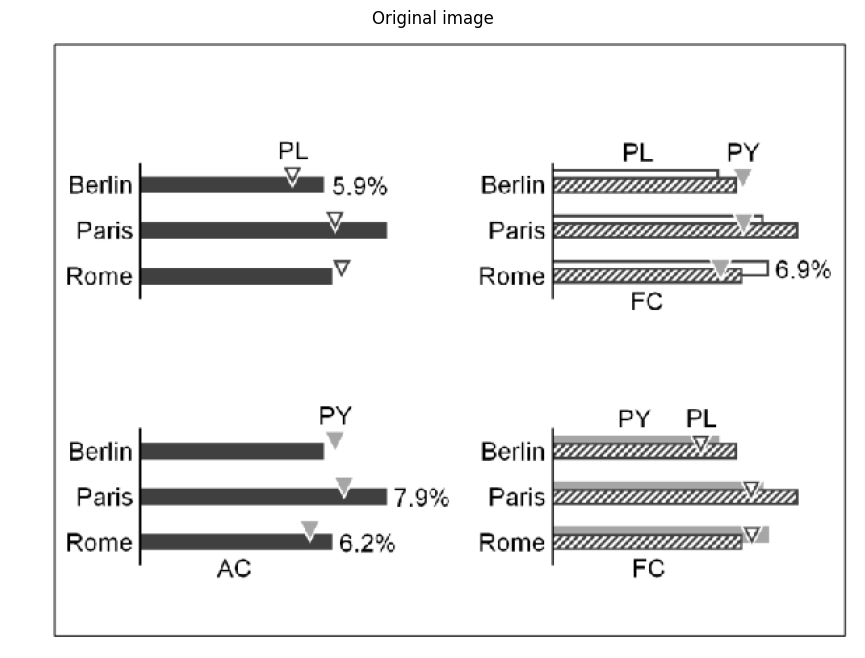

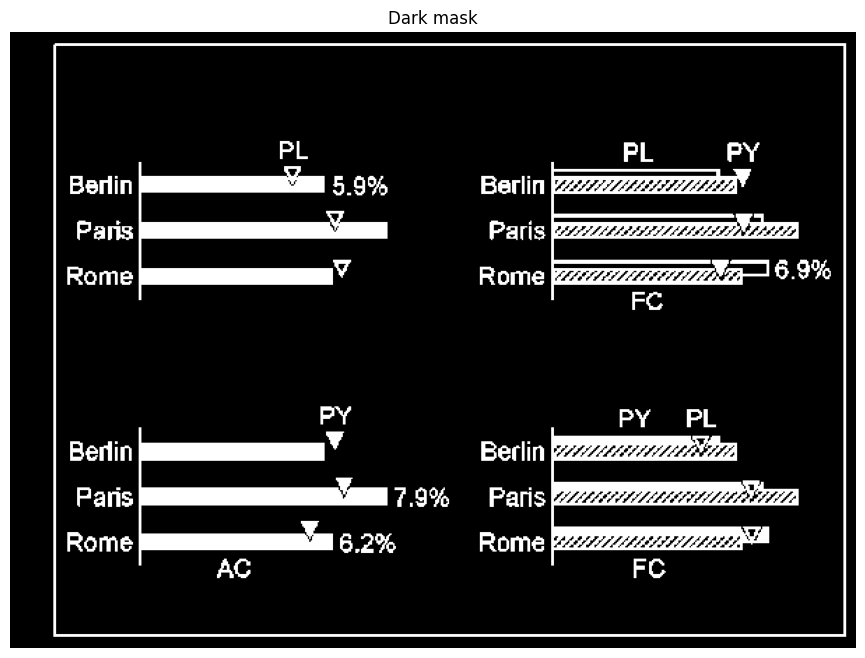

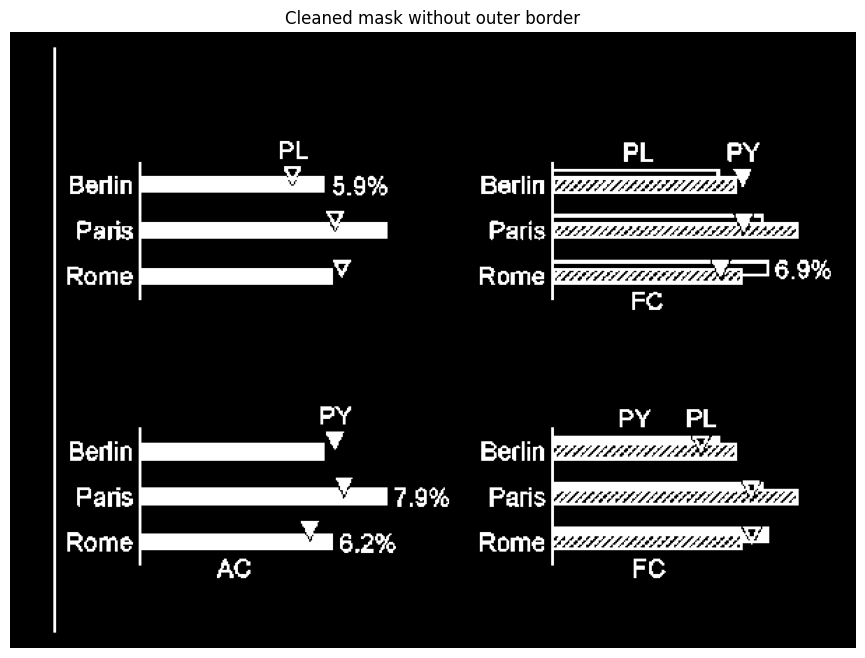

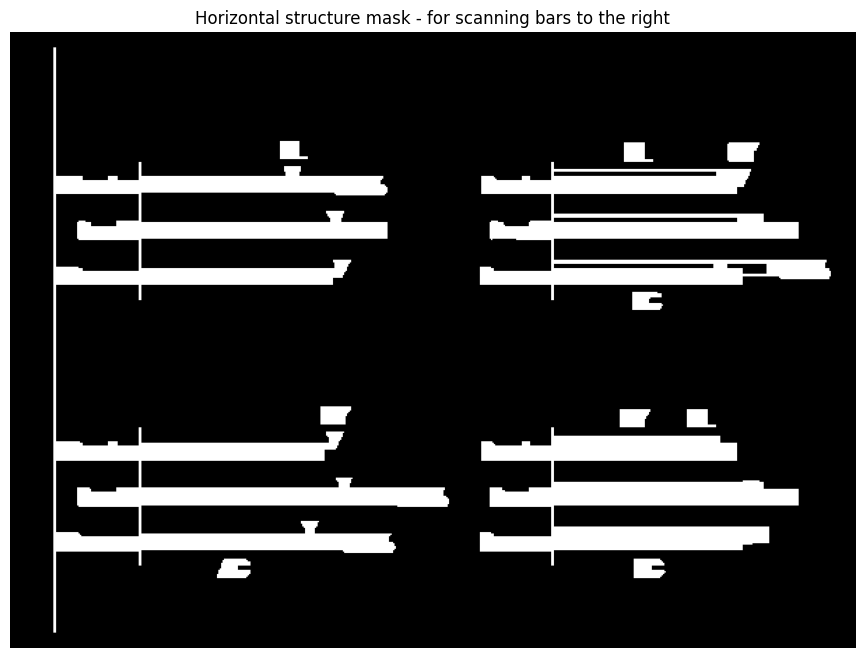

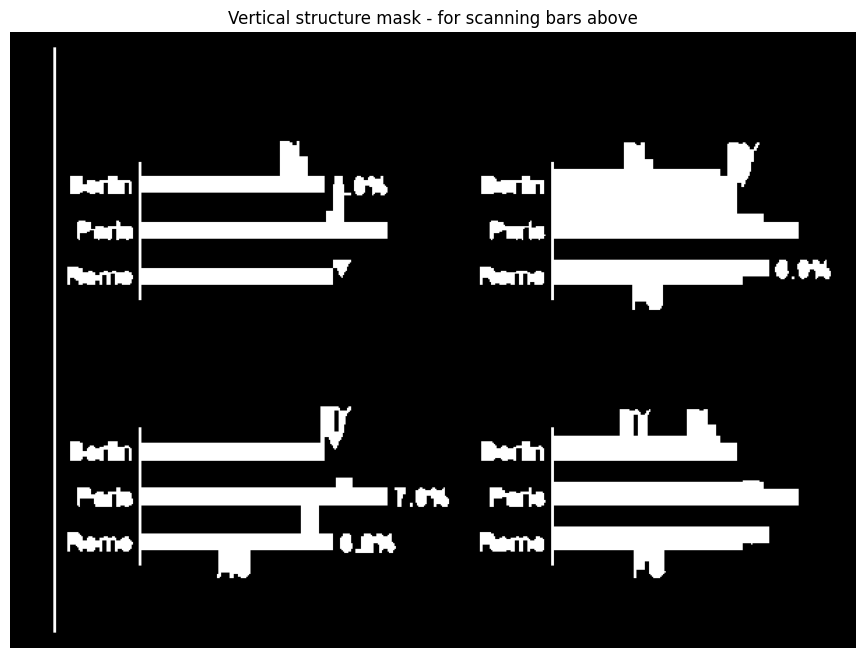

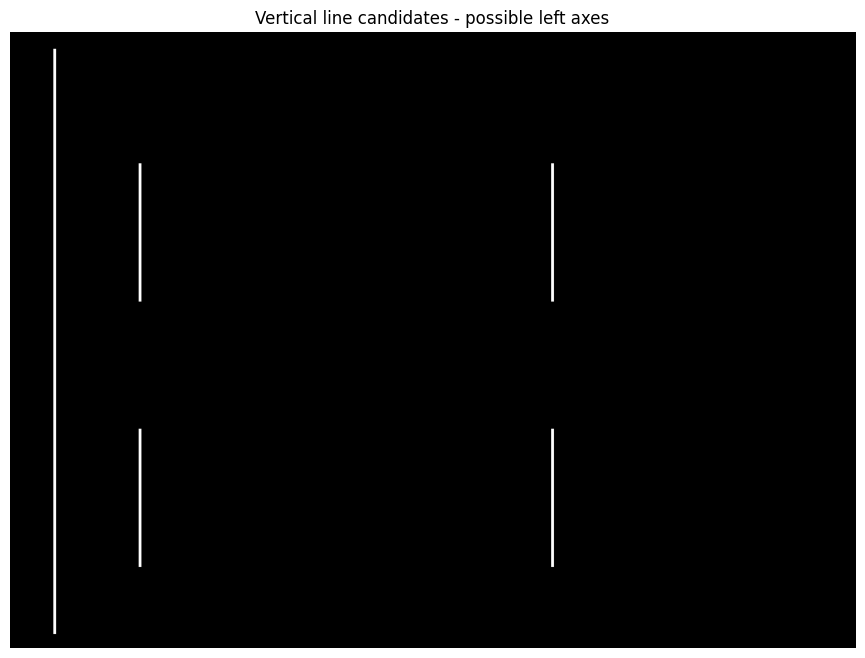

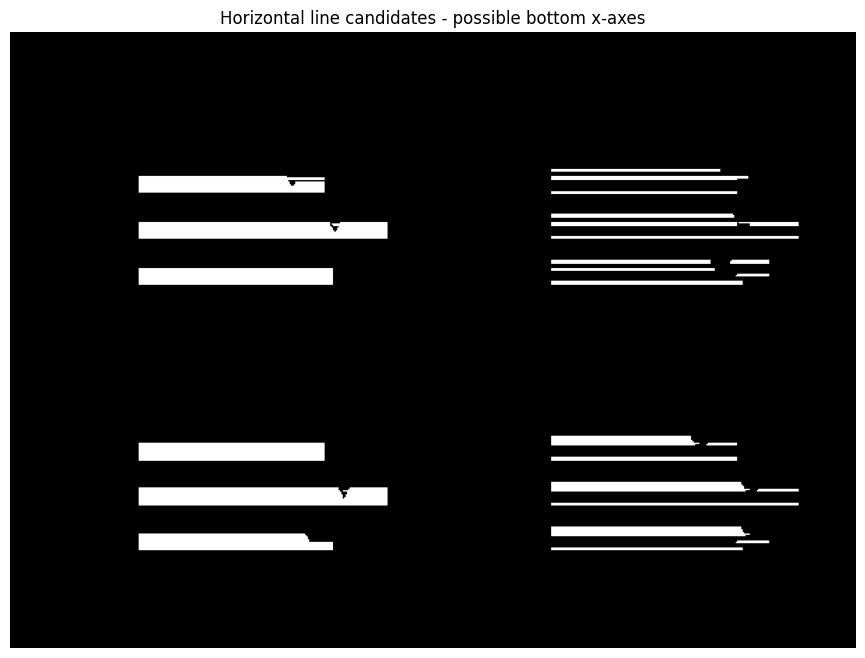

Vertical line candidates: 4
Horizontal line candidates: 18
Left axes found: 4
Bottom x-axes found: 3
Total axes found: 7


In [4]:
image = load_image(IMAGE_PATH)
show_image("Original image", image)

result = run_line_support_scanning_detection(image)

show_image("Dark mask", result["dark_mask"])
show_image("Cleaned mask without outer border", result["cleaned_mask"])

show_image("Horizontal structure mask - for scanning bars to the right", result["horizontal_structure_mask"])
show_image("Vertical structure mask - for scanning bars above", result["vertical_structure_mask"])

show_image("Vertical line candidates - possible left axes", result["vertical_lines_mask"])
show_image("Horizontal line candidates - possible bottom x-axes", result["horizontal_lines_mask"])

print("Vertical line candidates:", len(result["vertical_lines"]))
print("Horizontal line candidates:", len(result["horizontal_lines"]))
print("Left axes found:", len(result["left_axes"]))
print("Bottom x-axes found:", len(result["bottom_axes"]))
print("Total axes found:", len(result["axes"]))

## 4. Final detection result

Lichtroze/luchtgroen = ruwe lijnkandidaten  
Blauw = definitieve linker as voor horizontal bar charts  
Groen = definitieve onderste x-as voor vertical bar charts


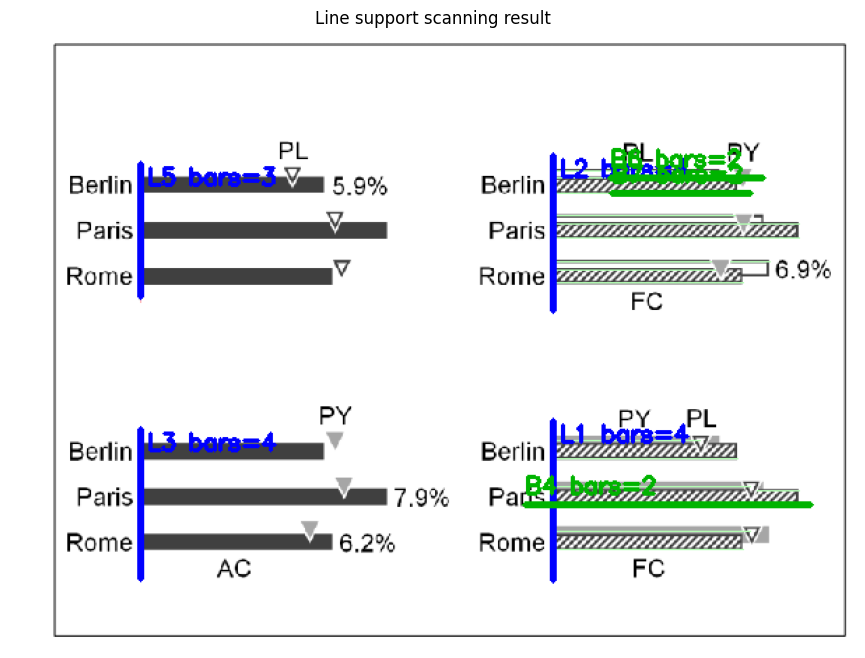

Saved result to: ..\output\7_line_support_scanning_axes.png


: 

In [ ]:
output = draw_result(image, result, max_axes=MAX_AXES_TO_DRAW)
show_image("Line support scanning result", output)

output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_line_support_scanning_axes.png"
cv2.imwrite(str(output_path), output)

print("Saved result to:", output_path)

## 5. Debug tables

In [ ]:
print("Vertical line candidates:")
display(lines_to_dataframe(result["vertical_lines"]))

print("Horizontal line candidates:")
display(lines_to_dataframe(result["horizontal_lines"]).head(50))

print("Detected axes:")
display(axes_to_dataframe(result["axes"]))

## 6. Batch test on all dataset images

In [ ]:
DATASET_DIR = Path("../Dataset")
BATCH_OUTPUT_DIR = OUTPUT_DIR / "line_support_scanning_batch"
BATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_extensions = [".png", ".jpg", ".jpeg", ".webp"]
image_paths = []

for ext in image_extensions:
    image_paths.extend(DATASET_DIR.rglob(f"*{ext}"))

print("Found images:", len(image_paths))

summary_rows = []

for path in image_paths:
    try:
        img = load_image(path)
        res = run_line_support_scanning_detection(img)
        out = draw_result(img, res, max_axes=MAX_AXES_TO_DRAW)

        relative = path.relative_to(DATASET_DIR)
        save_path = BATCH_OUTPUT_DIR / relative
        save_path.parent.mkdir(parents=True, exist_ok=True)

        cv2.imwrite(str(save_path), out)

        summary_rows.append({
            "image": str(relative),
            "vertical_line_candidates": len(res["vertical_lines"]),
            "horizontal_line_candidates": len(res["horizontal_lines"]),
            "left_axes": len(res["left_axes"]),
            "bottom_axes": len(res["bottom_axes"]),
            "total_axes": len(res["axes"]),
            "output": str(save_path)
        })

        print("Saved:", save_path)

    except Exception as e:
        print("Error with", path, ":", e)

summary_df = pd.DataFrame(summary_rows)
summary_df

## 7. Explanation for report

You can use this text:

> This notebook uses a rule-based OpenCV approach based on line support scanning. Instead of relying on bar contours, the method first detects possible axis lines and then checks whether those lines are supported by nearby bar pixels. For horizontal bar charts, the method detects vertical line candidates and scans directly to the right of each line. If multiple horizontal bar segments are found next to the line, it is accepted as a left-side axis. For vertical bar charts, the method detects horizontal line candidates and scans directly above each line. If multiple vertical bar segments are found above the line, it is accepted as a bottom x-axis. This approach is better suited for complex chart images where text, bars and labels can merge into one contour.

Limitation:

> This is a rule-based OpenCV method, not a trained deep learning model. It can still fail when bars are very small, when axis lines are missing, or when text and symbols create similar pixel patterns. Therefore, the detected axes should be treated as candidates and checked visually.
